#### KNN, example 2 - Titanic-data

**This example was based on the logistic regression example originally.**

In [1]:
# usual imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pip install scikit-learn
from sklearn.model_selection import train_test_split

# use KNN classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
# load data 
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
# let's study to first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Handling missing values and dropping unnecessary columns

In [4]:
# columns to drop => Name, Ticket, PassengerID
# these are meta-information (background information) and 
# can't be used for machine learning purposes
df = df.drop(["PassengerId", "Name", "Ticket"], axis=1)

In [5]:
# let's check data again
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [6]:
# how many rows in total do we have?
len(df)

891

In [7]:
# missing values per column
# Cabin is a problem, almost 80% of data is missing
# When too much data is missing, it's usually better just to drop the column if possible
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [8]:
# Cabin has most of the data missing, it's better drop than
# than attempt imputation, because it's going to generalize the data too much (statistically)
df = df.drop("Cabin", axis=1)

In [9]:
# let's check data again
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Example: imputation with a category based average

In [10]:
# instead of replacing the missing ages with average age of all passengers
# this is probably a better idea (plain average often simplifies statistics too much)
df.groupby(['Pclass'])['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [11]:
# let's fix the missing ages based on the price class and average age
def impute_age(row):
    age = row['Age']
    pclass = row['Pclass']

    # if age is missing => only then fix the age with imputation based on price class
    # (see the average ages above)
    # else => leave the age as it is
    if pd.isnull(age):
        if pclass == 1:
            return 38
        elif pclass == 2:
            return 30
        else:
            return 25
    else:
        return age

In [12]:
# use the imputation function to fix age
df['Age'] = df.apply(impute_age, axis=1)

In [13]:
# check if any data still missing
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [14]:
# just drop the two rows with missing Embarked values
df = df.dropna()

In [15]:
# good, no more missing values!
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [16]:
# and we only lost 2 rows in total, very good
# => we preserved almost all of the data
len(df)

889

In [17]:
# let's see what needs to be done next
# we have some categorical variables that need to be converted to numbers
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


#### Handling categorical variables (binary, ordinal, nominal)

In [18]:
# By looking at the data above, we have one binary variable and one nominal variable

# NO ORDINAL VARIABLES THIS TIME

# Sex -column => Binary (LabelEncoder)
# Embarked -column => Nominal (OneHotEncoder)

**Case 1: Binary variabels (categories with exactly two options)**

In [19]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder

# list of all boolean variables we want to convert
variables = ['Sex']

# initalize encoder and convert everything
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

**Case 2: Ordinal variables (categories that have an order/rank -> can be compared)**

In [20]:
# No ordinal categories in this dataset

**Case 3: Nominal categories (categories that can't be compared numerically)**

In [21]:
# this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder

# list of our nominal categories
variables = ['Embarked']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [22]:
# when using OneHotEncoder, we can always remove one (and exactly one)
# variable from the list PER converted nominal category variable
df = df.drop("Embarked_S", axis=1)

In [23]:
# let's check data again
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q
0,0,3,1,22.0,1,0,7.2500,0,0
1,1,1,0,38.0,1,0,71.2833,1,0
2,1,3,0,26.0,0,0,7.9250,0,0
3,1,1,0,35.0,1,0,53.1000,0,0
4,0,3,1,35.0,0,0,8.0500,0,0


In [24]:
# quick check on the correlation matrix, which variables
# affect the survived -target variable?
df.corr(numeric_only=True)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q
Survived,1.000000,-0.335549,-0.541585,-0.054934,-0.034040,0.083151,0.255290,0.169966,0.004536
Pclass,-0.335549,1.000000,0.127741,-0.401322,0.081656,0.016824,-0.548193,-0.245733,0.220558
Sex,-0.541585,0.127741,1.000000,0.085564,-0.116348,-0.247508,-0.179958,-0.084520,-0.075217
Age,-0.054934,-0.401322,0.085564,1.000000,-0.242834,-0.174280,0.118205,0.043681,-0.070847
SibSp,-0.034040,0.081656,-0.116348,-0.242834,1.000000,0.414542,0.160887,-0.060074,-0.026692
Parch,0.083151,0.016824,-0.247508,-0.174280,0.414542,1.000000,0.217532,-0.011588,-0.081585
Fare,0.255290,-0.548193,-0.179958,0.118205,0.160887,0.217532,1.000000,0.270731,-0.116684
Embarked_C,0.169966,-0.245733,-0.084520,0.043681,-0.060074,-0.011588,0.270731,1.000000,-0.148646
Embarked_Q,0.004536,0.220558,-0.075217,-0.070847,-0.026692,-0.081585,-0.116684,-0.148646,1.000000


#### X/y -split + VIF -test

In [25]:
# a small trick => use everything else except, the target
X = df.drop("Survived", axis=1)

# our target variable is y
y = df['Survived']

#### the rest should be the same, train/test -split, train model, metrics etc.

In [26]:
# create train/test split with scikit-learn's helper function
# random_state is optional, you can lock down the randomness for same results everytime
# this is sometimes helpful when you want to minimize randomness in order to maximize optimizations
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=24)

Based on iterations, best k-value is this:
12


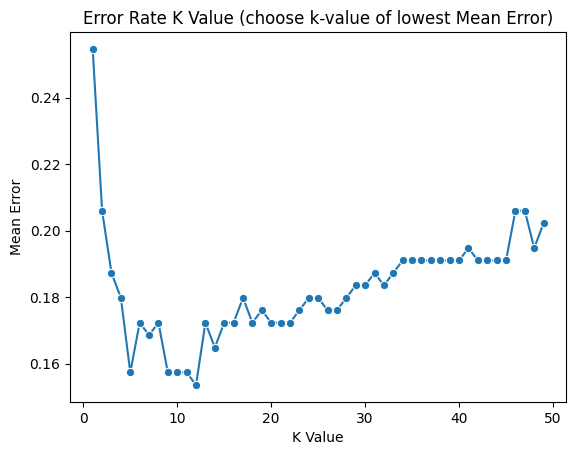

In [27]:
# CLASSIFIER VERSION
# adjust this to 50 or even 150 if you have lots of data rows
max_iterations = 50

# list to save the error values in the loop
error = []

# the default metric in scikit-learn
metric_selection = "minkowski"

# Calculating error for K values between 1 and 40
for i in range(1, max_iterations):

     # try with current k-value, train the model and make a test prediction
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=i, metric=metric_selection))
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)

    # save the error value for this k-value
    error.append(np.mean(pred_i != y_test))
    
# plot all the k-values and their error values
sns.lineplot(x=range(1, max_iterations), y=error, marker='o')
plt.title('Error Rate K Value (choose k-value of lowest Mean Error)')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

# choose best k-value based on metrics
# we have to add +1 to k-value, since argmin() returns an index
# which starts from 0, but k-values start from 1
print("Based on iterations, best k-value is this:")
k_value = np.argmin(error) + 1
print(k_value)

#### Create logistic regression model

In [28]:
# code as usual
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_value, metric=metric_selection))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(12)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depen

#### Classification error metrics

In [29]:
# get the test predictions for metrics as usual
predictions = model.predict(X_test)

In [30]:
# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89       169
           1       0.88      0.67      0.76        98

    accuracy                           0.85       267
   macro avg       0.86      0.81      0.82       267
weighted avg       0.85      0.85      0.84       267


Model overall accuracy: 84.64%


[[160   9]
 [ 32  66]]


<Axes: >

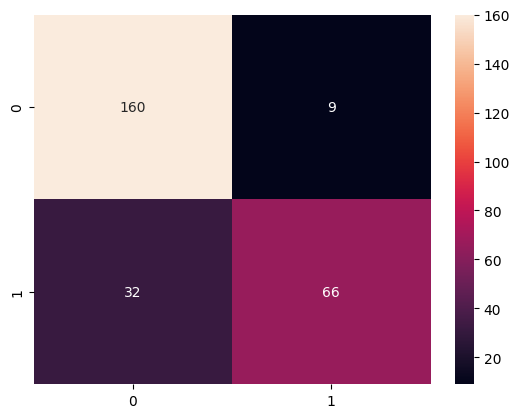

In [31]:
print(confusion_matrix(y_test, predictions))

# if you want a more graphical version of this, try:
# the fmt-parameter will change to decimal format from scientific format
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

In [32]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means, there's still something to optimize
# if this falls under 0.5, random guessing works better than this model
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# ~83-84%, which is pretty OK

0.8716036710542205

#### Let's try using the model in deciding a new imaginary person and if they survived or not

In [33]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_C', 'Embarked_Q'],
      dtype='object')

In [34]:
df.head(1)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q
0,0,3,1,22.0,1,0,7.25,0,0


In [36]:
# Sex -column: 0 => Female, 1 => Male
tester_row = {
    'Pclass': 2, 
    'Sex': 0, 
    'Age': 22, 
    'SibSp': 1, 
    'Parch': 0, 
    'Fare': 7.25,
    'Embarked_C': 0,
    'Embarked_Q': 0
}

# create a pandas DataFrame and scale the values
tester_row = pd.DataFrame([tester_row])

print("All probabilities by category:")
print(model.predict_proba(tester_row))
print()

# change these based on your original data
labels = ["No", "Yes"]

print("Did this passenger survive the Titanic (No/Yes):")
result = labels[model.predict(tester_row)[0]]
print(result)
print("-------------------")

All probabilities by category:
[[0.16666667 0.83333333]]

Did this passenger survive the Titanic (No/Yes):
Yes
-------------------
